In [1]:
import pandas as pd

# load dataset
df = pd.read_csv("../data/raw/jobs.csv")

# show first rows
df.head()

,job_title,company,location,salary_min,salary_max,experience_level,skills
0,Data Analyst,TechCorp,Johannesburg,25000,40000,Junior,"Python, SQL, Excel"
1,Data Scientist,AI Solutions,Cape Town,45000,70000,Mid,"Python, Machine Learning, SQL"
2,Machine Learning Engineer,FutureTech,Remote,60000,90000,Senior,"Python, TensorFlow, Deep Learning"
3,Business Analyst,FinServe,Johannesburg,30000,45000,Junior,"SQL, Excel, Power BI"
4,Data Engineer,CloudData,Durban,50000,75000,Mid,"Python, Spark, SQL"


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_title         6 non-null      object
 1   company           6 non-null      object
 2   location          6 non-null      object
 3   salary_min        6 non-null      int64 
 4   salary_max        6 non-null      int64 
 5   experience_level  6 non-null      object
 6   skills            6 non-null      object
dtypes: int64(2), object(5)
memory usage: 468.0+ bytes


In [3]:
df["salary_avg"] = (df["salary_min"] + df["salary_max"]) / 2

df[["job_title", "salary_avg"]]

,job_title,salary_avg
0,Data Analyst,32500.0
1,Data Scientist,57500.0
2,Machine Learning Engineer,75000.0
3,Business Analyst,37500.0
4,Data Engineer,62500.0
5,AI Engineer,85000.0


In [4]:
df["job_title"].value_counts()

job_title
Data Analyst                 1
Data Scientist               1
Machine Learning Engineer    1
Business Analyst             1
Data Engineer                1
AI Engineer                  1
Name: count, dtype: int64

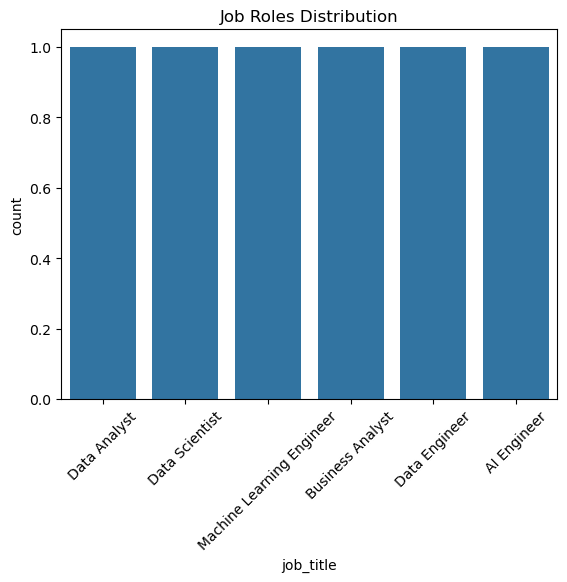

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="job_title")

plt.xticks(rotation=45)
plt.title("Job Roles Distribution")

plt.show()

In [6]:
df["skills"]


0                   Python, SQL, Excel
1        Python, Machine Learning, SQL
2    Python, TensorFlow, Deep Learning
3                 SQL, Excel, Power BI
4                   Python, Spark, SQL
5       Python, Deep Learning, PyTorch
Name: skills, dtype: object

In [7]:
df["skills_list"] = df["skills"].str.split(",")

df[["job_title", "skills_list"]]

,job_title,skills_list
0,Data Analyst,"[Python, SQL, Excel]"
1,Data Scientist,"[Python, Machine Learning, SQL]"
2,Machine Learning Engineer,"[Python, TensorFlow, Deep Learning]"
3,Business Analyst,"[SQL, Excel, Power BI]"
4,Data Engineer,"[Python, Spark, SQL]"
5,AI Engineer,"[Python, Deep Learning, PyTorch]"


In [8]:
all_skills = df["skills_list"].explode()

all_skills


0               Python
0                  SQL
0                Excel
1               Python
1     Machine Learning
1                  SQL
2               Python
2           TensorFlow
2        Deep Learning
3                  SQL
3                Excel
3             Power BI
4               Python
4                Spark
4                  SQL
5               Python
5        Deep Learning
5              PyTorch
Name: skills_list, dtype: object

In [9]:
all_skills = all_skills.str.strip()

In [10]:
skill_counts = all_skills.value_counts()

skill_counts

skills_list
Python              5
SQL                 4
Excel               2
Deep Learning       2
Machine Learning    1
TensorFlow          1
Power BI            1
Spark               1
PyTorch             1
Name: count, dtype: int64

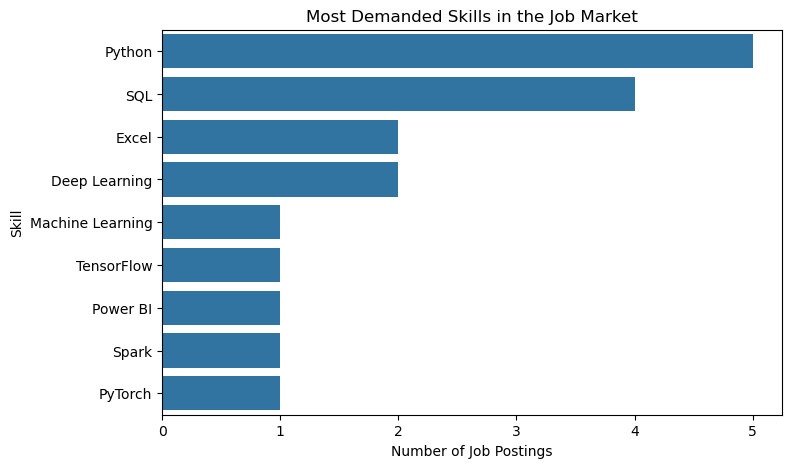

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x=skill_counts.values,
    y=skill_counts.index
)

plt.title("Most Demanded Skills in the Job Market")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")

plt.show()

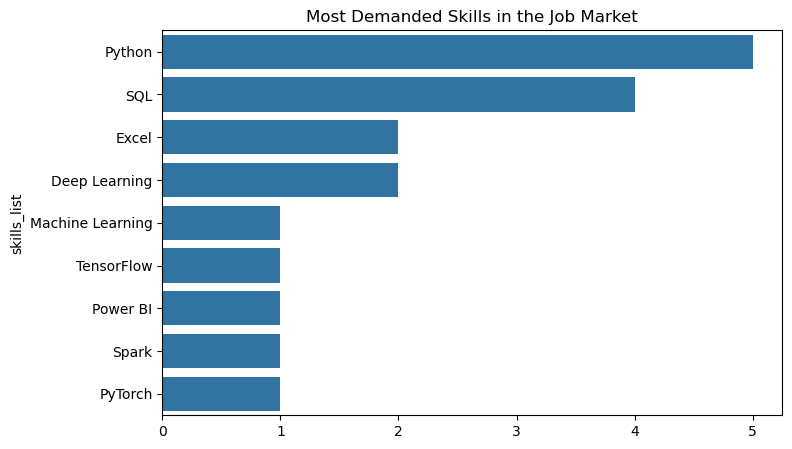

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=skill_counts.values,
    y=skill_counts.index
)

plt.title("Most Demanded Skills in the Job Market")

plt.savefig("../outputs/charts/top_skills.png")

plt.show()

In [13]:
df[["job_title", "salary_avg"]]


,job_title,salary_avg
0,Data Analyst,32500.0
1,Data Scientist,57500.0
2,Machine Learning Engineer,75000.0
3,Business Analyst,37500.0
4,Data Engineer,62500.0
5,AI Engineer,85000.0


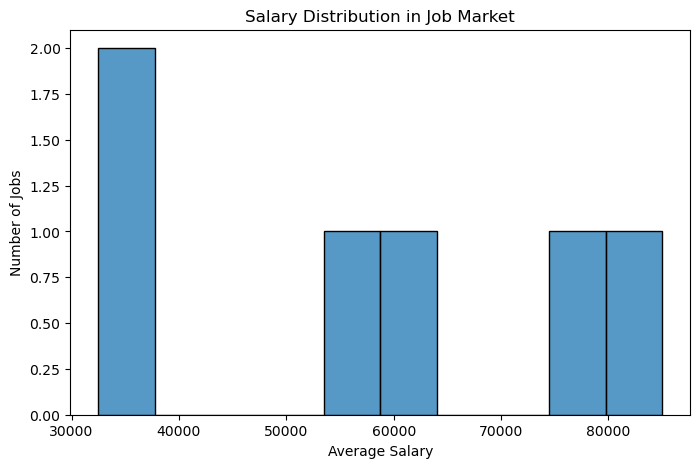

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df["salary_avg"], bins=10)

plt.title("Salary Distribution in Job Market")
plt.xlabel("Average Salary")
plt.ylabel("Number of Jobs")

plt.show()


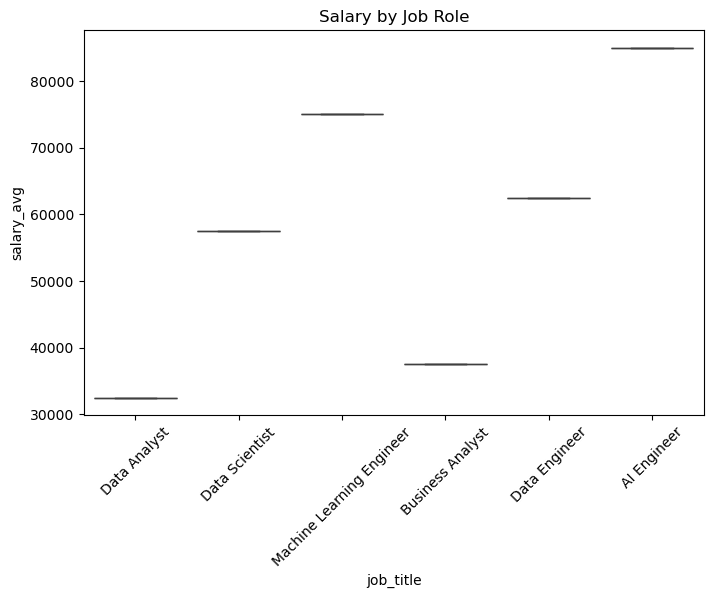

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="job_title", y="salary_avg")

plt.xticks(rotation=45)
plt.title("Salary by Job Role")

plt.show()

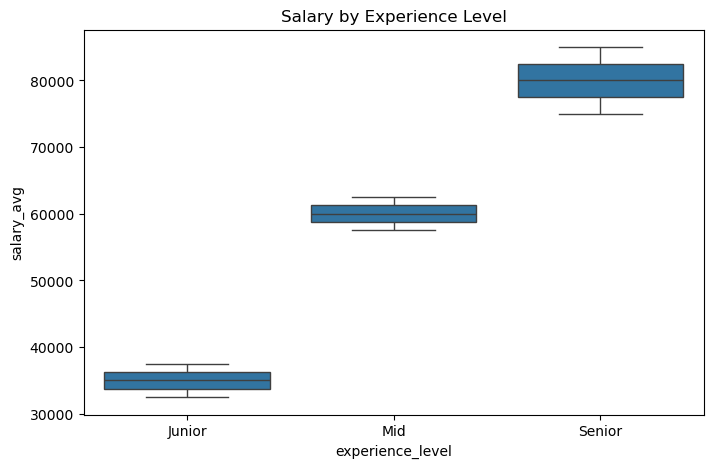

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="experience_level", y="salary_avg")

plt.title("Salary by Experience Level")

plt.show()

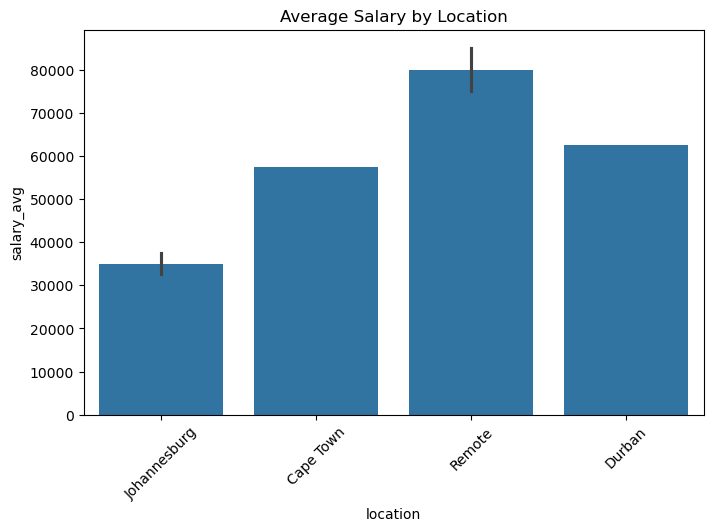

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="location", y="salary_avg")

plt.xticks(rotation=45)
plt.title("Average Salary by Location")

plt.show()


In [18]:
role_salary = df.groupby("job_title")["salary_avg"].mean()

role_salary.sort_values(ascending=False)

job_title
AI Engineer                  85000.0
Machine Learning Engineer    75000.0
Data Engineer                62500.0
Data Scientist               57500.0
Business Analyst             37500.0
Data Analyst                 32500.0
Name: salary_avg, dtype: float64

In [19]:
plt.savefig("../outputs/charts/salary_by_role.png")

<Figure size 640x480 with 0 Axes>

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd

In [21]:
X = df[["job_title", "location", "experience_level"]]
y = df["salary_avg"]

In [22]:
X = pd.get_dummies(X)

In [23]:
X.head()

,job_title_AI Engineer,job_title_Business Analyst,job_title_Data Analyst,job_title_Data Engineer,job_title_Data Scientist,job_title_Machine Learning Engineer,location_Cape Town,location_Durban,location_Johannesburg,location_Remote,experience_level_Junior,experience_level_Mid,experience_level_Senior
0,False,False,True,False,False,False,False,False,True,False,True,False,False
1,False,False,False,False,True,False,True,False,False,False,False,True,False
2,False,False,False,False,False,True,False,False,False,True,False,False,True
3,False,True,False,False,False,False,False,False,True,False,True,False,False
4,False,False,False,True,False,False,False,True,False,False,False,True,False


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [26]:
predictions = model.predict(X_test)

predictions

array([45416.66666667, 61666.66666667])

In [27]:
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 92100694.44444443


In [28]:
sample = pd.DataFrame({
    "job_title": ["Data Scientist"],
    "location": ["Cape Town"],
    "experience_level": ["Mid"]
})

sample = pd.get_dummies(sample)
sample = sample.reindex(columns=X.columns, fill_value=0)

model.predict(sample)

array([61666.66666667])

In [29]:
import joblib

joblib.dump(model, "../models/salary_model.pkl")

['../models/salary_model.pkl']